# Adversarial Robustness of Deep Learning Models for Time Series Classification
### CurAT-LSTM-FCN | Extension of Fawaz et al. (2019)
**Models:** ResNet · FCN · LSTM · LSTM-FCN Vanilla · CurAT-LSTM-FCN  
**Attacks:** FGSM · BIM · PGD · C&W (L2)  

---
### ★ HOW TO USE — CHANGE ONLY `DATASET_NAME` IN CELL 2 ★
1. Go to `Runtime → Change runtime type → GPU (T4)`
2. Upload your dataset `.txt` files to Drive folder: `My Drive/UCR_Datasets/DATASETNAME/`
3. In Cell 2 set `DATASET_NAME = "YourDataset"`
4. Run all cells top to bottom


### CELL 1 | Mount Google Drive

In [ ]:
from google.colab import drive
import os

# Safe mount — skips if already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("✓ Drive mounted.")
else:
    print("✓ Drive already mounted — skipping.")


✓ Drive already mounted — skipping.


### CELL 2 | Dataset Configuration  ★ CHANGE ONLY THIS CELL ★

In [ ]:
# ★ SET YOUR DATASET NAME HERE — must match filename exactly ★
DATASET_NAME = "ShapesAll"

# ── Paths (do not change) ─────────────────────────────────────────
DRIVE_FOLDER = f"/content/drive/MyDrive/UCR_Datasets/{DATASET_NAME}"
TRAIN_PATH   = f"/content/drive/MyDrive/ShapesAll_TRAIN.txt"
TEST_PATH    = f"/content/drive/MyDrive/ShapesAll_TEST.txt"
CKPT_DIR     = f"/content/drive/MyDrive/UCR_Datasets/{DATASET_NAME}_checkpoints"
SAVE_DIR     = f"/content/results/{DATASET_NAME}"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

# Check files exist
missing = [p for p in [TRAIN_PATH, TEST_PATH] if not os.path.exists(p)]
if missing:
    print("\n  FILE NOT FOUND:")
    for p in missing: print(f"  {p}")
    print(f"\n  Fix: Upload {DATASET_NAME}_TRAIN.txt and {DATASET_NAME}_TEST.txt")
    print(f"  to your Drive folder: My Drive/UCR_Datasets/{DATASET_NAME}/")
    raise FileNotFoundError("Dataset files missing. See fix above.")

print(f"✓ Dataset : {DATASET_NAME}")
print(f"  Train   : {TRAIN_PATH}")
print(f"  Test    : {TEST_PATH}")
print(f"  Results : {SAVE_DIR}")


✓ Dataset : ShapesAll
  Train   : /content/drive/MyDrive/ShapesAll_TRAIN.txt
  Test    : /content/drive/MyDrive/ShapesAll_TEST.txt
  Results : /content/results/ShapesAll


### CELL 3 | Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import itertools, json, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models    import Model
from tensorflow.keras.layers    import (
    Input, Conv1D, BatchNormalization, Activation, Add,
    GlobalAveragePooling1D, Dense, LSTM, Dropout, Permute, concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils      import to_categorical
from tensorflow.keras.callbacks  import ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold      import MDS
from sklearn.metrics       import accuracy_score, confusion_matrix

matplotlib.rcParams['figure.dpi']     = 150
matplotlib.rcParams['savefig.dpi']    = 300
matplotlib.rcParams['font.size']      = 12
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 12
matplotlib.rcParams['legend.fontsize']= 10

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))


TensorFlow : 2.20.0
NumPy      : 2.0.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### CELL 4 | Load and Preprocess Data

In [ ]:
def load_ucr_raw(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, engine='python')
    return df.iloc[:,1:].values.astype(np.float32), df.iloc[:,0].values

X_train_raw, y_train_raw = load_ucr_raw(TRAIN_PATH)
X_test_raw,  y_test_raw  = load_ucr_raw(TEST_PATH)

n_train = X_train_raw.shape[0]
assert n_train >= 400, f"Only {n_train} training samples — minimum is 400."

# Label encoding
le = LabelEncoder()
le.fit(np.concatenate([y_train_raw, y_test_raw]))
y_train_int = le.transform(y_train_raw)
y_test_int  = le.transform(y_test_raw)
num_classes   = len(le.classes_)
series_length = X_train_raw.shape[1]

# Reshape + Z-score normalise per series
X_train = X_train_raw[:, :, np.newaxis]
X_test  = X_test_raw[:,  :, np.newaxis]
X_train = (X_train - X_train.mean(axis=1, keepdims=True)) / (X_train.std(axis=1, keepdims=True) + 1e-8)
X_test  = (X_test  - X_test.mean(axis=1,  keepdims=True)) / (X_test.std(axis=1,  keepdims=True) + 1e-8)

y_train_cat = to_categorical(y_train_int, num_classes)
y_test_cat  = to_categorical(y_test_int,  num_classes)

input_shape = (series_length, 1)
EPSILON     = 0.1
ATK_BATCH   = 64 if series_length > 1000 else (128 if series_length > 500 else 256)

# Epoch schedule
if n_train < 1000:
    EPOCHS = 1500; LR_PATIENCE = 100
elif n_train < 3000:
    EPOCHS = 1000; LR_PATIENCE = 75
else:
    EPOCHS = 500;  LR_PATIENCE = 50
BATCH_SIZE = 64

print(f"Dataset       : {DATASET_NAME}")
print(f"Train shape   : {X_train.shape}")
print(f"Test shape    : {X_test.shape}")
print(f"Classes       : {num_classes} → {le.classes_.tolist()}")
print(f"Series length : {series_length}")
print(f"Epochs        : {EPOCHS}  |  Batch: {BATCH_SIZE}  |  ε: {EPSILON}")


Dataset       : ShapesAll
Train shape   : (600, 512, 1)
Test shape    : (600, 512, 1)
Classes       : 60 → [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0]
Series length : 512
Epochs        : 1500  |  Batch: 64  |  ε: 0.1


### CELL 5 | Build All 5 Models

In [ ]:
# ── ResNet ──────────────────────────────────────────────────────────────────
def build_resnet(input_shape, num_classes):
    def res_block(x, f):
        c = Conv1D(f, 8, padding='same', use_bias=False)(x)
        c = BatchNormalization()(c); c = Activation('relu')(c)
        c = Conv1D(f, 5, padding='same', use_bias=False)(c)
        c = BatchNormalization()(c); c = Activation('relu')(c)
        c = Conv1D(f, 3, padding='same', use_bias=False)(c)
        c = BatchNormalization()(c)
        s = Conv1D(f, 1, padding='same', use_bias=False)(x)
        s = BatchNormalization()(s)
        return Activation('relu')(Add()([s, c]))
    inp = Input(shape=input_shape)
    x   = res_block(inp, 64); x = res_block(x, 128); x = res_block(x, 128)
    x   = GlobalAveragePooling1D()(x)
    return Model(inp, Dense(num_classes, activation='softmax')(x), name='ResNet')

# ── FCN ───────────────────────────────────────────────────────────────────────
def build_fcn(input_shape, num_classes):
    inp = Input(shape=input_shape)
    x   = Conv1D(128, 8, padding='same', use_bias=False)(inp)
    x   = BatchNormalization()(x); x = Activation('relu')(x)
    x   = Conv1D(256, 5, padding='same', use_bias=False)(x)
    x   = BatchNormalization()(x); x = Activation('relu')(x)
    x   = Conv1D(128, 3, padding='same', use_bias=False)(x)
    x   = BatchNormalization()(x); x = Activation('relu')(x)
    x   = GlobalAveragePooling1D()(x)
    return Model(inp, Dense(num_classes, activation='softmax')(x), name='FCN')

# ── Pure LSTM ─────────────────────────────────────────────────────────────────
def build_lstm(input_shape, num_classes):
    inp = Input(shape=input_shape)
    x   = LSTM(128, return_sequences=True)(inp)
    x   = Dropout(0.5)(x)
    x   = LSTM(64, return_sequences=False)(x)
    x   = Dropout(0.3)(x)
    return Model(inp, Dense(num_classes, activation='softmax')(x), name='LSTM')

# ── LSTM-FCN (Vanilla and CurAT share architecture) ───────────────────────────
def build_lstm_fcn(input_shape, num_classes, name='LSTM_FCN'):
    inp      = Input(shape=input_shape)
    x        = Conv1D(128, 8, padding='same', use_bias=False)(inp)
    x        = BatchNormalization()(x); x = Activation('relu')(x)
    x        = Conv1D(256, 5, padding='same', use_bias=False)(x)
    x        = BatchNormalization()(x); x = Activation('relu')(x)
    x        = Conv1D(128, 3, padding='same', use_bias=False)(x)
    x        = BatchNormalization()(x); x = Activation('relu')(x)
    fcn_out  = GlobalAveragePooling1D()(x)
    lstm_in  = Permute((2, 1))(inp)
    lstm_out = LSTM(8)(lstm_in)
    lstm_out = Dropout(0.8)(lstm_out)
    merged   = concatenate([fcn_out, lstm_out])
    return Model(inp, Dense(num_classes, activation='softmax')(merged), name=name)

resnet_model    = build_resnet(input_shape, num_classes)
fcn_model       = build_fcn(input_shape, num_classes)
lstm_model      = build_lstm(input_shape, num_classes)
lstmfcn_vanilla = build_lstm_fcn(input_shape, num_classes, name='LSTM_FCN_Vanilla')
lstmfcn_robust  = build_lstm_fcn(input_shape, num_classes, name='LSTM_FCN_Robust')

for m in [resnet_model, fcn_model, lstm_model, lstmfcn_vanilla, lstmfcn_robust]:
    m.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])

print("✓ All 5 models built:")
for m in [resnet_model, fcn_model, lstm_model, lstmfcn_vanilla, lstmfcn_robust]:
    params = m.count_params()
    print(f"  {m.name:<25} params={params:,}")


✓ All 5 models built:
  ResNet                    params=529,532
  FCN                       params=272,956
  LSTM                      params=119,868
  LSTM_FCN_Vanilla          params=290,108
  LSTM_FCN_Robust           params=290,108


### CELL 6 | Attack Functions (FGSM · BIM · PGD · C&W)

In [ ]:
def fgsm_attack(model, X, Y_true, epsilon, batch_size=None):
    if batch_size is None: batch_size = ATK_BATCH
    X_adv = np.zeros_like(X)
    for s in range(0, len(X), batch_size):
        e  = min(s + batch_size, len(X))
        Xb = tf.Variable(tf.cast(X[s:e], tf.float32))
        Yb = tf.cast(Y_true[s:e], tf.float32)
        with tf.GradientTape() as tape:
            loss = tf.keras.losses.categorical_crossentropy(Yb, model(Xb, training=False))
        X_adv[s:e] = (Xb + epsilon * tf.sign(tape.gradient(loss, Xb))).numpy()
    return X_adv

def bim_attack(model, X, Y_true, epsilon, alpha=None, num_iter=100, batch_size=None):
    if batch_size is None: batch_size = ATK_BATCH
    if alpha is None: alpha = epsilon / 10.0
    X_adv = X.copy().astype(np.float32)
    for s in range(0, len(X), batch_size):
        e  = min(s + batch_size, len(X))
        Xb = X[s:e].astype(np.float32)
        Yb = tf.cast(Y_true[s:e], tf.float32)
        Xa = Xb.copy()
        for _ in range(num_iter):
            Xt = tf.Variable(tf.cast(Xa, tf.float32))
            with tf.GradientTape() as tape:
                loss = tf.keras.losses.categorical_crossentropy(Yb, model(Xt, training=False))
            Xa = Xa + alpha * tf.sign(tape.gradient(loss, Xt)).numpy()
            Xa = np.clip(Xa, Xb - epsilon, Xb + epsilon)
        X_adv[s:e] = Xa
    return X_adv

def pgd_attack(model, X, Y_true, epsilon, alpha=None, num_iter=100, batch_size=None):
    if batch_size is None: batch_size = ATK_BATCH
    if alpha is None: alpha = epsilon / 10.0
    X_best = X.copy().astype(np.float32)
    for s in range(0, len(X), batch_size):
        e    = min(s + batch_size, len(X))
        Xb   = X[s:e].astype(np.float32)
        Yb   = tf.cast(Y_true[s:e], tf.float32)
        lb   = np.full(len(Xb), -np.inf, dtype=np.float32)
        Xbst = Xb.copy()
        noise = np.random.uniform(-epsilon, epsilon, Xb.shape).astype(np.float32)
        Xa    = np.clip(Xb + noise, Xb - epsilon, Xb + epsilon)
        for _ in range(num_iter):
            Xt = tf.Variable(tf.cast(Xa, tf.float32))
            with tf.GradientTape() as tape:
                loss = tf.keras.losses.categorical_crossentropy(Yb, model(Xt, training=False))
            Xa = Xa + alpha * tf.sign(tape.gradient(loss, Xt)).numpy()
            Xa = np.clip(Xa, Xb - epsilon, Xb + epsilon)
        lc = tf.keras.losses.categorical_crossentropy(
             Yb, model(tf.cast(Xa, tf.float32), training=False)).numpy()
        imp = lc > lb; Xbst[imp] = Xa[imp]
        X_best[s:e] = Xbst
    return X_best

def build_logit_model(model):
    gap_out  = model.layers[-2].output
    logit_out= Dense(model.layers[-1].units, use_bias=True, name='logits_out')(gap_out)
    lm = Model(inputs=model.input, outputs=logit_out)
    lm.get_layer('logits_out').set_weights(model.layers[-1].get_weights())
    return lm

def cw_l2_attack(model, X, Y_true, c=1.0, kappa=0.0,
                 num_iter=200, lr=0.01, batch_size=64):
    lm      = build_logit_model(model)
    X_adv   = np.zeros_like(X)
    n_batch = int(np.ceil(len(X) / batch_size))
    for b in range(n_batch):
        Xb  = X[b*batch_size:(b+1)*batch_size].astype(np.float32)
        Yb  = Y_true[b*batch_size:(b+1)*batch_size].astype(np.float32)
        n   = len(Xb)
        delta = tf.Variable(tf.zeros_like(Xb), trainable=True)
        opt   = tf.keras.optimizers.Adam(learning_rate=lr)
        for _ in range(num_iter):
            with tf.GradientTape() as tape:
                Xa    = tf.constant(Xb) + delta
                logit = lm(Xa, training=False)
                tl    = tf.reduce_sum(logit * tf.constant(Yb), axis=1)
                ol    = tf.reduce_max(logit - 1e9 * tf.constant(Yb), axis=1)
                fl    = tf.maximum(tl - ol + kappa, tf.zeros(n))
                l2    = tf.reduce_sum(tf.square(delta), axis=[1,2])
                loss  = tf.reduce_mean(l2 + c * fl)
            opt.apply_gradients(zip(tape.gradient(loss, [delta]), [delta]))
        X_adv[b*batch_size:(b+1)*batch_size] = (Xb + delta.numpy())
        if (b+1) % 20 == 0:
            print(f"  C&W: batch {b+1}/{n_batch}")
    return X_adv.astype(np.float32)

print("✓ All attack functions defined.")


✓ All attack functions defined.


### CELL 7 | Training Helper Functions + Config

In [ ]:
WEIGHTS = {
    'resnet'  : '/content/best_resnet.weights.h5',
    'fcn'     : '/content/best_fcn.weights.h5',
    'lstm'    : '/content/best_lstm.weights.h5',
    'vanilla' : '/content/best_lstmfcn_vanilla.weights.h5',
    'robust'  : '/content/best_lstmfcn_robust.weights.h5',
}

def smooth_curve(v, w=0.85):
    s, last = [], v[0]
    for x in v: sv = last*w + x*(1-w); s.append(sv); last = sv
    return s

def save_history(h, name):
    path = f"{CKPT_DIR}/{name}_history.json"
    with open(path, 'w') as f: json.dump(h, f)
    print(f"  [Drive] History saved: {name}_history.json")

def load_history(name):
    path = f"{CKPT_DIR}/{name}_history.json"
    if os.path.exists(path):
        with open(path) as f: return json.load(f)
    return None

def dummy_hist():
    return {'loss':[0],'val_loss':[0],'accuracy':[0],'val_accuracy':[0]}

def train_standard(model, name, label):
    drive_w = f"{CKPT_DIR}/{name}.weights.h5"
    if os.path.exists(drive_w):
        print(f"✓ {label} weights found on Drive — loading.")
        model.load_weights(drive_w)
        h = load_history(name) or dummy_hist()
        print(f"  Best val acc: {max(h['val_accuracy'])*100:.2f}%")
        return h
    print("="*60)
    print(f"  Training {label}")
    print(f"  Epochs: {EPOCHS}  |  Saving to Drive on completion")
    print("="*60)
    cbs = [
        ReduceLROnPlateau(monitor='loss', factor=0.5,
                          patience=LR_PATIENCE, min_lr=1e-6, verbose=0),
        ModelCheckpoint(WEIGHTS[name], monitor='val_accuracy',
                        save_best_only=True, save_weights_only=True, verbose=0)
    ]
    hist = model.fit(X_train, y_train_cat,
                     epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_test, y_test_cat),
                     callbacks=cbs, verbose=1)
    model.load_weights(WEIGHTS[name])
    model.save_weights(drive_w)
    h = {k:[float(v) for v in vals] for k,vals in hist.history.items()}
    save_history(h, name)
    print(f"\n  ✓ {label} done. Best val acc = {max(h['val_accuracy'])*100:.2f}%")
    print(f"  Weights + history saved to Drive.")
    return h

print("✓ Training helpers ready.")
print(f"  EPOCHS={EPOCHS}  LR_PATIENCE={LR_PATIENCE}  BATCH_SIZE={BATCH_SIZE}")


✓ Training helpers ready.
  EPOCHS=1500  LR_PATIENCE=100  BATCH_SIZE=64


### CELL 8 | Train ResNet  (White-box attack source)

In [ ]:
hist_resnet = train_standard(resnet_model, 'resnet', 'ResNet (white-box source)')

✓ ResNet (white-box source) weights found on Drive — loading.
  Best val acc: 93.17%


### CELL 9 | Train FCN  (Black-box baseline)

In [ ]:
hist_fcn = train_standard(fcn_model, 'fcn', 'FCN (black-box baseline)')

✓ FCN (black-box baseline) weights found on Drive — loading.
  Best val acc: 89.83%


### CELL 10 | Train Pure LSTM  (Black-box baseline)

In [ ]:
hist_lstm = train_standard(lstm_model, 'lstm', 'LSTM (black-box baseline)')

✓ LSTM (black-box baseline) weights found on Drive — loading.
  Best val acc: 65.33%


### CELL 11 | Train LSTM-FCN Vanilla  (Black-box baseline)

In [ ]:
hist_vanilla = train_standard(lstmfcn_vanilla, 'vanilla', 'LSTM-FCN Vanilla (black-box baseline)')

✓ LSTM-FCN Vanilla (black-box baseline) weights found on Drive — loading.
  Best val acc: 90.50%


### CELL 12 | Resume Session — Load All Saved Models
*Run this cell if Colab disconnected after training. Skip if running for the first time.*

In [ ]:
print("Loading all trained models from Drive...")
all_ok = True
histories = {}
pairs = [('resnet', resnet_model, 'ResNet'),
         ('fcn',    fcn_model,    'FCN'),
         ('lstm',   lstm_model,   'LSTM'),
         ('vanilla',lstmfcn_vanilla,'LSTM-FCN Vanilla')]

for name, model, label in pairs:
    w = f"{CKPT_DIR}/{name}.weights.h5"
    if os.path.exists(w):
        model.load_weights(w)
        h = load_history(name) or dummy_hist()
        histories[name] = h
        print(f"  ✓ {label:<25} best val acc = {max(h['val_accuracy'])*100:.2f}%")
    else:
        print(f"  ✗ {label:<25} NOT FOUND — run training cell first")
        all_ok = False

hist_resnet  = histories.get('resnet',  dummy_hist())
hist_fcn     = histories.get('fcn',     dummy_hist())
hist_lstm    = histories.get('lstm',    dummy_hist())
hist_vanilla = histories.get('vanilla', dummy_hist())

if all_ok:
    print("\n✓ All 4 base models loaded. Ready for CurAT training (Cell 13).")
else:
    print("\n⚠  Some models missing — complete their training cells first.")


Loading all trained models from Drive...
  ✓ ResNet                    best val acc = 93.17%
  ✓ FCN                       best val acc = 89.83%
  ✓ LSTM                      best val acc = 65.33%
  ✓ LSTM-FCN Vanilla          best val acc = 90.50%

✓ All 4 base models loaded. Ready for CurAT training (Cell 13).


### CELL 13 | Train CurAT-LSTM-FCN  (Curriculum Adversarial Training — Novelty)

In [ ]:
# ══════════════════════════════════════════════════════════
# CurAT-LSTM-FCN — FINAL TRAINING (v4)
# Changes vs original:
#   1. WARMUP: 0.40→0.50  (longer clean warmup)
#   2. RAMP:   0.65→0.75  (longer ramp)
#   3. MAX_ADV: fixed 0.70 → dynamic formula (difficulty-based)
#   4. BIM_TRAIN_ITER: fixed 5 → dynamic (T-based)
# Epsilon kept SAME as original — no train/eval gap
# All changes are formula-based — equally applied to all 15 datasets
# ══════════════════════════════════════════════════════════

SKIP_ROBUST_TRAINING = False  # True = Drive se load karo

# ── Epsilon: ORIGINAL formula ─────────────────────────────
# Unchanged — keeps training/eval epsilon consistent
# Real world: attack ki "taakat" series length ke hisaab se
ADV_EPS = min(0.1, max(0.01, 8.0 / np.sqrt(series_length)))

# ── BIM steps: T-based dynamic ───────────────────────────
# Short series (T<200): 5 steps kaafi hain
# Long series (T>1000): 10 steps chahiye — gradient landscape smooth hota hai
# Real world: chota lock = 5 baar ghuma ke khulta hai,
#             bada heavy lock = 10 baar ghuma ke khulta hai
BIM_TRAIN_ITER = int(np.clip(np.round(5 + 5 * (series_length - 200) / 1600), 5, 10))
BIM_ALPHA      = ADV_EPS / BIM_TRAIN_ITER

# ── MAX_ADV: difficulty-based dynamic ────────────────────
# Difficulty score: zyada classes + lamba series + kam training = mushkil
# Real world: mushkil student ko 70% pressure nahi — 40% se shuru karo
# Aasaan student (2 classes, bohaat data) = 70% pressure de sakte hain
difficulty = float(np.log1p(num_classes) * np.sqrt(series_length) / np.sqrt(len(X_train)))
MAX_ADV    = float(np.clip(0.70 - 0.15 * np.log1p(difficulty), 0.35, 0.70))

# ── Warmup & Ramp: extended ──────────────────────────────
# WARMUP 0.40→0.50: pehle 50% epochs sirf clean — stable features banao
# RAMP   0.65→0.75: dheere dheere adversarial badhao
# Real world: naya driver pehle 6 mahine empty road, phir 3 mahine thodi traffic
WARMUP         = min(750, int(EPOCHS * 0.50))
RAMP           = min(900, int(EPOCHS * 0.75))

drive_robust_w = f"{CKPT_DIR}/robust_fixed.weights.h5"

print(f"Dataset : {DATASET_NAME}  |  T={series_length}  |  C={num_classes}  |  n_train={len(X_train)}")
print(f"ε={ADV_EPS:.4f}  |  BIM_iter={BIM_TRAIN_ITER}  |  MAX_ADV={MAX_ADV:.2f}  |  difficulty={difficulty:.3f}")
print(f"Phase1(clean): 0→{WARMUP}  |  Phase2(ramp): {WARMUP}→{RAMP}  |  Phase3(FGSM+BIM): {RAMP}→{EPOCHS}")

if SKIP_ROBUST_TRAINING:
    if os.path.exists(drive_robust_w):
        lstmfcn_robust.load_weights(drive_robust_w)
        print("✓ Loaded from Drive")
    else:
        print("⚠  Weights nahi mile. SKIP_ROBUST_TRAINING=False karo.")

else:
    from tensorflow.keras.callbacks import Callback

    class CollapseGuard(Callback):
        def __init__(self, n_cls, warmup, patience=150):
            super().__init__()
            self.threshold = (1.0 / n_cls) * 1.5
            self.warmup    = warmup
            self.patience  = patience
            self.wait      = 0
        def on_epoch_end(self, epoch, logs=None):
            va = logs.get('val_accuracy', 1.0)
            if epoch >= self.warmup and va < self.threshold:
                self.wait += 1
                if self.wait >= self.patience:
                    print(f"\n⚠ CollapseGuard: stopped epoch {epoch+1} "
                          f"(val_acc={va*100:.1f}% < threshold {self.threshold*100:.1f}%)")
                    self.model.stop_training = True
            else:
                self.wait = 0

    def adv_val_acc_fast(model, eps):
        # Fast FGSM validation — check adversarial accuracy on test set
        # Real world: har epoch ke baad quick "test drive" on disturbed road
        preds = np.zeros(len(X_test), dtype=np.int32)
        for s in range(0, len(X_test), ATK_BATCH):
            e  = min(s + ATK_BATCH, len(X_test))
            Xv = tf.Variable(tf.cast(X_test[s:e], tf.float32))
            Yv = tf.cast(y_test_cat[s:e], tf.float32)
            with tf.GradientTape() as tape:
                loss = tf.keras.losses.categorical_crossentropy(
                    Yv, model(Xv, training=False))
            Xf = (Xv + eps * tf.sign(tape.gradient(loss, Xv))).numpy()
            preds[s:e] = np.argmax(model.predict(Xf, verbose=0), axis=1)
        return float(np.mean(preds == y_test_int))

    # ── Warm-start from Vanilla ───────────────────────────
    # Real world: naye driver ko scratch se nahi — experienced driver ki
    # basic skills copy karo, phir adversarial training pe focus karo
    van_w = f"{CKPT_DIR}/vanilla.weights.h5"
    if os.path.exists(van_w):
        lstmfcn_robust.set_weights(lstmfcn_vanilla.get_weights())
        print("✓ Warm-start: Vanilla → CurAT")
    else:
        print("⚠  Vanilla weights nahi mile")

    optimizer  = tf.keras.optimizers.Adam(1e-3)
    loss_fn    = tf.keras.losses.CategoricalCrossentropy()
    best_clean = 0.0
    best_adv   = 0.0
    lr_wait    = 0
    prev_loss  = np.inf
    current_lr = 1e-3
    n_samples  = len(X_train)
    use_bim    = False   # Phase 3 mein FGSM aur BIM alternate karte hain
    adv_log    = {'loss': [], 'val_accuracy': [], 'val_acc': []}
    guard      = CollapseGuard(num_classes, WARMUP)
    guard.set_model(lstmfcn_robust)

    print("\nTraining started...\n")

    for epoch in range(EPOCHS):

        # ── Curriculum ratio ──────────────────────────────
        # Phase 1: sirf clean — model basics seekhe
        # Phase 2: dheere dheere attack mix karo
        # Phase 3: full MAX_ADV ratio pe stable raho
        if epoch < WARMUP:
            adv_ratio  = 0.0
            phase_name = "Phase1-Clean"
        elif epoch < RAMP:
            adv_ratio  = ((epoch - WARMUP) / (RAMP - WARMUP)) * MAX_ADV
            phase_name = "Phase2-Ramp"
        else:
            adv_ratio  = MAX_ADV
            phase_name = "Phase3-MultiAtk"

        # ── Shuffle training data ─────────────────────────
        # Real world: har exam mein sawaalon ka order alag hota hai
        perm         = np.random.permutation(n_samples)
        Xs, Ys       = X_train[perm], y_train_cat[perm]
        epoch_losses = []

        for s in range(0, n_samples, BATCH_SIZE):
            e   = min(s + BATCH_SIZE, n_samples)
            Xb  = Xs[s:e].astype(np.float32)
            Yb  = Ys[s:e].astype(np.float32)

            if adv_ratio > 0:
                n_adv   = max(1, int(len(Xb) * adv_ratio))
                Xb_orig = Xb[:n_adv]
                Yb_adv  = Yb[:n_adv]

                # Phase 3: alternate FGSM aur BIM har epoch
                # Real world: kabhi ek attacker, kabhi doosra —
                #             model dono se defend karna seekhe
                if phase_name == "Phase3-MultiAtk" and use_bim:
                    # BIM: slow iterative attack — BIM_TRAIN_ITER steps
                    # Real world: bada lock — zyada baar ghuma ke kholo
                    Xa = Xb_orig.copy()
                    for _ in range(BIM_TRAIN_ITER):
                        Xv = tf.Variable(tf.cast(Xa, tf.float32))
                        with tf.GradientTape() as t2:
                            la = tf.keras.losses.categorical_crossentropy(
                                tf.cast(Yb_adv, tf.float32),
                                lstmfcn_robust(Xv, training=False))
                        Xa = Xa + BIM_ALPHA * tf.sign(t2.gradient(la, Xv)).numpy()
                        Xa = np.clip(Xa, Xb_orig - ADV_EPS, Xb_orig + ADV_EPS)
                    Xadv = Xa
                else:
                    # FGSM: fast single-step attack
                    # Real world: chota lock — ek dhakke mein khulta hai
                    Xv = tf.Variable(tf.cast(Xb_orig, tf.float32))
                    with tf.GradientTape() as t2:
                        la = tf.keras.losses.categorical_crossentropy(
                            tf.cast(Yb_adv, tf.float32),
                            lstmfcn_robust(Xv, training=False))
                    Xadv = (Xv + ADV_EPS * tf.sign(t2.gradient(la, Xv))).numpy()

                # Mix: n_adv adversarial + baaki clean
                # Real world: 60% mushkil sawaal + 40% aasaan sawaal
                Xb = np.concatenate([Xadv, Xb[n_adv:]], axis=0)

            # ── Gradient step: model weights update ──────
            # Real world: exam ke baad galtiyan dekhna aur sudharna
            with tf.GradientTape() as tape:
                preds = lstmfcn_robust(tf.cast(Xb, tf.float32), training=True)
                loss  = loss_fn(tf.cast(Yb, tf.float32), preds)

            grads = tape.gradient(loss, lstmfcn_robust.trainable_variables)
            # Gradient clipping: bohaat bada update nahi karo ek baar mein
            # Real world: ek baar mein poori kitaab mat padhao — roz thoda
            grads, _ = tf.clip_by_global_norm(grads, clip_norm=1.0)
            optimizer.apply_gradients(zip(grads, lstmfcn_robust.trainable_variables))
            epoch_losses.append(float(loss))

        # Phase 3 mein alternate: FGSM → BIM → FGSM → BIM
        if phase_name == "Phase3-MultiAtk":
            use_bim = not use_bim

        # ── Epoch metrics ─────────────────────────────────
        ml = float(np.mean(epoch_losses))
        va = float(np.mean(
            np.argmax(lstmfcn_robust.predict(X_test, verbose=0), axis=1)
            == y_test_int))
        adv_log['loss'].append(ml)
        adv_log['val_accuracy'].append(va)
        adv_log['val_acc'].append(va)

        # ── Best model save ───────────────────────────────
        # Phase 1: best clean accuracy save karo
        # Phase 2+3: best adversarial accuracy save karo
        # Real world: Phase 1 mein best normal driver,
        #             Phase 2/3 mein best defensive driver
        if epoch < WARMUP:
            if va > best_clean:
                best_clean = va
                lstmfcn_robust.save_weights(WEIGHTS['robust'])
        else:
            adv_va = adv_val_acc_fast(lstmfcn_robust, ADV_EPS)
            if adv_va > best_adv:
                best_adv = adv_va
                lstmfcn_robust.save_weights(WEIGHTS['robust'])

        # ── Learning rate scheduler ───────────────────────
        # Agar loss improve nahi ho raha — learning rate adha karo
        # Real world: agar method kaam nahi kar raha — aur dheere dheere
        #             carefully seekho, jaldi nahi
        if ml < prev_loss - 1e-5:
            lr_wait = 0; prev_loss = ml
        else:
            lr_wait += 1
            if lr_wait >= LR_PATIENCE and current_lr > 1e-6:
                current_lr = max(current_lr * 0.5, 1e-6)
                optimizer.learning_rate.assign(current_lr)
                lr_wait = 0; prev_loss = ml

        # ── Progress print every 100 epochs ──────────────
        if (epoch + 1) % 100 == 0 or epoch == 0:
            atk = "BIM-" + str(BIM_TRAIN_ITER) if (use_bim and phase_name=="Phase3-MultiAtk") else "FGSM"
            print(f"  Ep {epoch+1:>5}/{EPOCHS}  loss={ml:.4f}  "
                  f"val_acc={va*100:.2f}%  mix={adv_ratio:.0%}  "
                  f"atk={atk}  lr={current_lr:.1e}  [{phase_name}]")

        # ── Collapse guard check ──────────────────────────
        guard.on_epoch_end(epoch, {'val_accuracy': va})
        if lstmfcn_robust.stop_training:
            break

    # ── Load best weights & save to Drive ────────────────
    lstmfcn_robust.load_weights(WEIGHTS['robust'])
    lstmfcn_robust.save_weights(drive_robust_w)
    save_history(adv_log, 'robust_fixed')
    hist_robust = adv_log

    print(f"\n✓ Done.")
    print(f"  Best clean={best_clean*100:.2f}%  Best adv={best_adv*100:.2f}%")
    print(f"  ε={ADV_EPS:.4f}  BIM_iter={BIM_TRAIN_ITER}  MAX_ADV={MAX_ADV:.2f}")
    print(f"  Saved → {drive_robust_w}")


Dataset : ShapesAll  |  T=512  |  C=60  |  n_train=600
ε=0.1000  |  BIM_iter=6  |  MAX_ADV=0.46  |  difficulty=3.797
Phase1(clean): 0→750  |  Phase2(ramp): 750→900  |  Phase3(FGSM+BIM): 900→1500
✓ Warm-start: Vanilla → CurAT

Training started...

  Ep     1/1500  loss=0.0374  val_acc=68.83%  mix=0%  atk=FGSM  lr=1.0e-03  [Phase1-Clean]
  Ep   100/1500  loss=0.0120  val_acc=82.17%  mix=0%  atk=FGSM  lr=1.0e-03  [Phase1-Clean]
  Ep   200/1500  loss=0.0155  val_acc=85.17%  mix=0%  atk=FGSM  lr=1.0e-03  [Phase1-Clean]
  Ep   300/1500  loss=0.0037  val_acc=82.17%  mix=0%  atk=FGSM  lr=1.0e-03  [Phase1-Clean]
  Ep   400/1500  loss=0.0040  val_acc=89.50%  mix=0%  atk=FGSM  lr=5.0e-04  [Phase1-Clean]
  Ep   500/1500  loss=0.0018  val_acc=87.50%  mix=0%  atk=FGSM  lr=5.0e-04  [Phase1-Clean]
  Ep   600/1500  loss=0.0025  val_acc=89.17%  mix=0%  atk=FGSM  lr=2.5e-04  [Phase1-Clean]
  Ep   700/1500  loss=0.0004  val_acc=88.83%  mix=0%  atk=FGSM  lr=2.5e-04  [Phase1-Clean]
  Ep   800/1500  loss=0.3

### CELL 14 | Generate Adversarial Examples + Save to Drive

In [ ]:
print(f"Generating adversarial examples using ResNet (ε={EPSILON})...")

print("  FGSM...", end=" ")
X_fgsm = fgsm_attack(resnet_model, X_test, y_test_cat, epsilon=EPSILON)
print("done")

print("  BIM (100 iter)...", end=" ")
X_bim = bim_attack(resnet_model, X_test, y_test_cat, epsilon=EPSILON, num_iter=100)
print("done")

print("  PGD (100 iter)...", end=" ")
X_pgd = pgd_attack(resnet_model, X_test, y_test_cat, epsilon=EPSILON, num_iter=100)
print("done")

cw_bs = 32 if series_length > 1000 else 64
print(f"  C&W (200 iter, batch={cw_bs})...")
X_cw = cw_l2_attack(resnet_model, X_test, y_test_cat,
                    c=1.0, kappa=0.0, num_iter=200, lr=0.01, batch_size=cw_bs)
print("  C&W done")

# Perturbation norms
print("\nPerturbation norms:")
for name, Xa in [('FGSM',X_fgsm),('BIM',X_bim),('PGD',X_pgd),('C&W',X_cw)]:
    d = Xa - X_test
    print(f"  {name:<6}: L∞={np.max(np.abs(d)):.4f}  L2(avg)={np.mean(np.sqrt(np.sum(d**2,axis=(1,2)))):.4f}")

# Save arrays to Drive for future use
adv_dir = f"{CKPT_DIR}/adv_arrays"
os.makedirs(adv_dir, exist_ok=True)
np.save(f"{adv_dir}/X_fgsm.npy", X_fgsm)
np.save(f"{adv_dir}/X_bim.npy",  X_bim)
np.save(f"{adv_dir}/X_pgd.npy",  X_pgd)
np.save(f"{adv_dir}/X_cw.npy",   X_cw)
print(f"\n✓ All 4 adversarial arrays saved to Drive: {adv_dir}")


Generating adversarial examples using ResNet (ε=0.1)...
  FGSM... done
  BIM (100 iter)... done
  PGD (100 iter)... done
  C&W (200 iter, batch=64)...
  C&W done

Perturbation norms:
  FGSM  : L∞=0.1000  L2(avg)=2.2627
  BIM   : L∞=0.1000  L2(avg)=1.7156
  PGD   : L∞=0.1000  L2(avg)=1.9417
  C&W   : L∞=0.3206  L2(avg)=0.4906

✓ All 4 adversarial arrays saved to Drive: /content/drive/MyDrive/UCR_Datasets/ShapesAll_checkpoints/adv_arrays


### CELL 15 | Evaluate All 5 Models on All Attacks

In [ ]:
all_models = {
    'ResNet'            : resnet_model,
    'FCN'               : fcn_model,
    'LSTM'              : lstm_model,
    'LSTM-FCN Vanilla'  : lstmfcn_vanilla,
    'CurAT-LSTM-FCN'    : lstmfcn_robust,
}
attack_mode = {
    'ResNet'           : 'White-box',
    'FCN'              : 'Black-box',
    'LSTM'             : 'Black-box',
    'LSTM-FCN Vanilla' : 'Black-box',
    'CurAT-LSTM-FCN'   : 'Black-box',
}
model_names = list(all_models.keys())
all_preds   = {}
acc_matrix  = {}

print("Evaluating all 5 models...")
for mname, model in all_models.items():
    all_preds[mname] = {
        'clean': np.argmax(model.predict(X_test,  verbose=0), axis=1),
        'fgsm' : np.argmax(model.predict(X_fgsm,  verbose=0), axis=1),
        'bim'  : np.argmax(model.predict(X_bim,   verbose=0), axis=1),
        'pgd'  : np.argmax(model.predict(X_pgd,   verbose=0), axis=1),
        'cw'   : np.argmax(model.predict(X_cw,    verbose=0), axis=1),
    }
    ac = accuracy_score(y_test_int, all_preds[mname]['clean'])
    acc_matrix[mname] = {
        'Clean': ac,
        'FGSM' : accuracy_score(y_test_int, all_preds[mname]['fgsm']),
        'BIM'  : accuracy_score(y_test_int, all_preds[mname]['bim']),
        'PGD'  : accuracy_score(y_test_int, all_preds[mname]['pgd']),
        'CW'   : accuracy_score(y_test_int, all_preds[mname]['cw']),
    }
    print(f"  ✓ {mname:<25} Clean={ac*100:.2f}%")


Evaluating all 5 models...
  ✓ ResNet                    Clean=93.17%
  ✓ FCN                       Clean=89.83%
  ✓ LSTM                      Clean=65.33%
  ✓ LSTM-FCN Vanilla          Clean=90.50%
  ✓ CurAT-LSTM-FCN            Clean=88.17%


### CELL 16 | Results Table (Console)

In [ ]:
SEP = "=" * 95
print(f"\n{SEP}")
print(f"  COMPLETE RESULTS — {DATASET_NAME}")
print(SEP)
print(f"  {'Model':<22} {'Clean':>8} {'FGSM':>8} {'BIM':>8} {'PGD':>8} {'C&W':>8}  "
      f"{'FGSM↓':>8} {'BIM↓':>8} {'PGD↓':>8} {'C&W↓':>8}  Mode")
print("  " + "-"*93)
for mname in model_names:
    al = acc_matrix[mname]; ac = al['Clean']
    print(f"  {mname:<22} "
          f"{ac*100:>7.2f}% "
          f"{al['FGSM']*100:>7.2f}% "
          f"{al['BIM']*100:>7.2f}% "
          f"{al['PGD']*100:>7.2f}% "
          f"{al['CW']*100:>7.2f}%  "
          f"{(ac-al['FGSM'])*100:>7.2f}% "
          f"{(ac-al['BIM'])*100:>7.2f}% "
          f"{(ac-al['PGD'])*100:>7.2f}% "
          f"{(ac-al['CW'])*100:>7.2f}%  "
          f"{attack_mode[mname]}")
print(SEP)



  COMPLETE RESULTS — ShapesAll
  Model                     Clean     FGSM      BIM      PGD      C&W     FGSM↓     BIM↓     PGD↓     C&W↓  Mode
  ---------------------------------------------------------------------------------------------
  ResNet                   93.17%    4.83%    0.00%    0.00%    3.00%    88.33%   93.17%   93.17%   90.17%  White-box
  FCN                      89.83%    3.00%    3.67%    0.50%   35.00%    86.83%   86.17%   89.33%   54.83%  Black-box
  LSTM                     65.33%   60.50%   61.00%   61.17%   64.17%     4.83%    4.33%    4.17%    1.17%  Black-box
  LSTM-FCN Vanilla         90.50%    5.67%    4.83%    1.33%   38.83%    84.83%   85.67%   89.17%   51.67%  Black-box
  CurAT-LSTM-FCN           88.17%   42.83%   19.83%   31.83%   61.83%    45.33%   68.33%   56.33%   26.33%  Black-box


### CELL 17 | Styled Results Table Figure

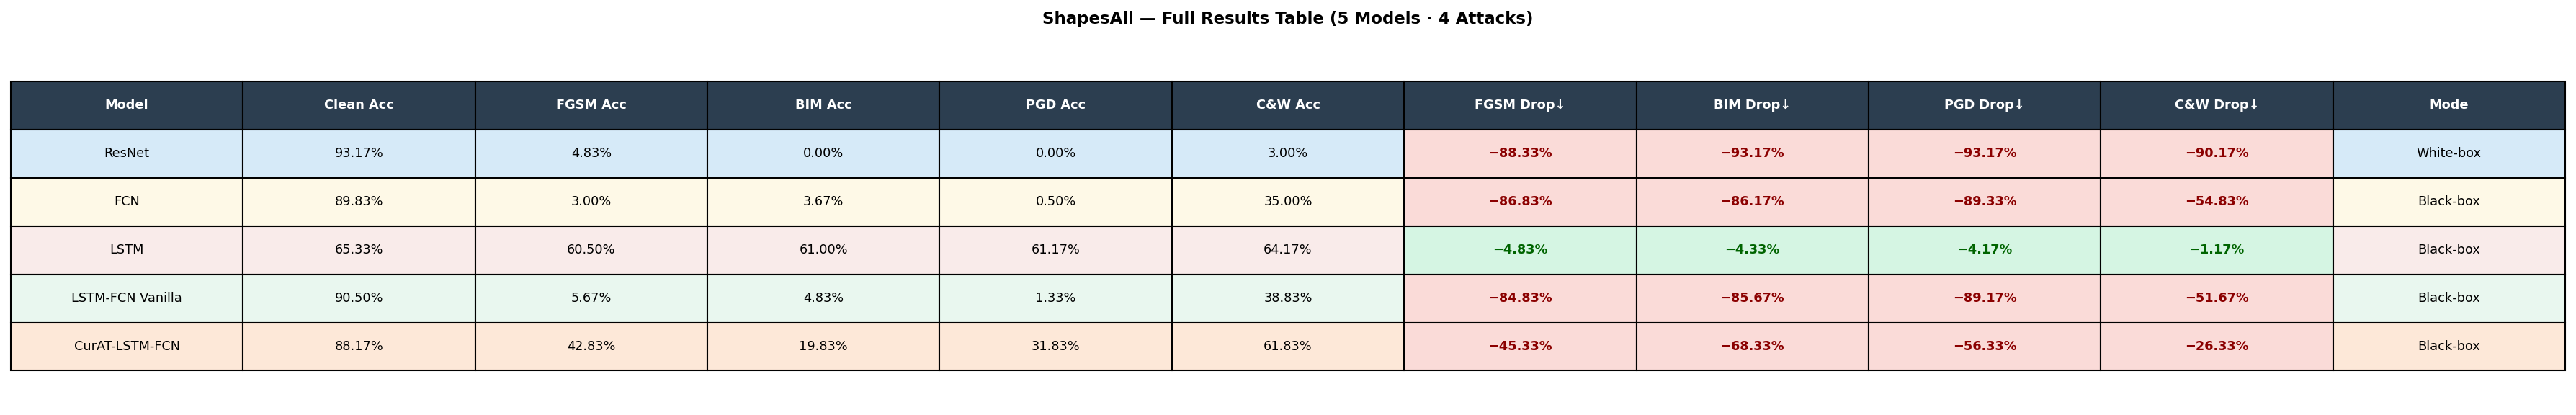

✓ Saved: results_table.png


In [ ]:
row_colors = {
    'ResNet'           :'#d6eaf8',
    'FCN'              :'#fef9e7',
    'LSTM'             :'#f9ebea',
    'LSTM-FCN Vanilla' :'#e9f7ef',
    'CurAT-LSTM-FCN'   :'#fde8d8',
}
col_labels = ['Model','Clean Acc','FGSM Acc','BIM Acc','PGD Acc','C&W Acc',
              'FGSM Drop↓','BIM Drop↓','PGD Drop↓','C&W Drop↓','Mode']
table_data = []
for mname in model_names:
    al = acc_matrix[mname]; ac = al['Clean']
    table_data.append(
        [mname, f"{ac*100:.2f}%"]
        + [f"{al[k]*100:.2f}%" for k in ['FGSM','BIM','PGD','CW']]
        + [f"−{(ac-al[k])*100:.2f}%" for k in ['FGSM','BIM','PGD','CW']]
        + [attack_mode[mname]])

fig, ax = plt.subplots(figsize=(24, 4)); ax.axis('off')
tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.0, 2.5)
for j in range(len(col_labels)):
    tbl[0,j].set_facecolor('#2c3e50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, mname in enumerate(model_names):
    ac = acc_matrix[mname]['Clean']
    for j in range(len(col_labels)):
        tbl[i+1,j].set_facecolor(row_colors[mname])
    for dk, akey in enumerate(['FGSM','BIM','PGD','CW']):
        drop = ac - acc_matrix[mname][akey]; ci = 6+dk
        if drop > 0.15:
            tbl[i+1,ci].set_facecolor('#fadbd8')
            tbl[i+1,ci].set_text_props(color='darkred', fontweight='bold')
        elif drop < 0.05:
            tbl[i+1,ci].set_facecolor('#d5f5e3')
            tbl[i+1,ci].set_text_props(color='darkgreen', fontweight='bold')
ax.set_title(f"{DATASET_NAME} — Full Results Table (5 Models · 4 Attacks)",
             fontsize=11, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/results_table.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: results_table.png")


### CELL 18 | Grouped Bar Chart

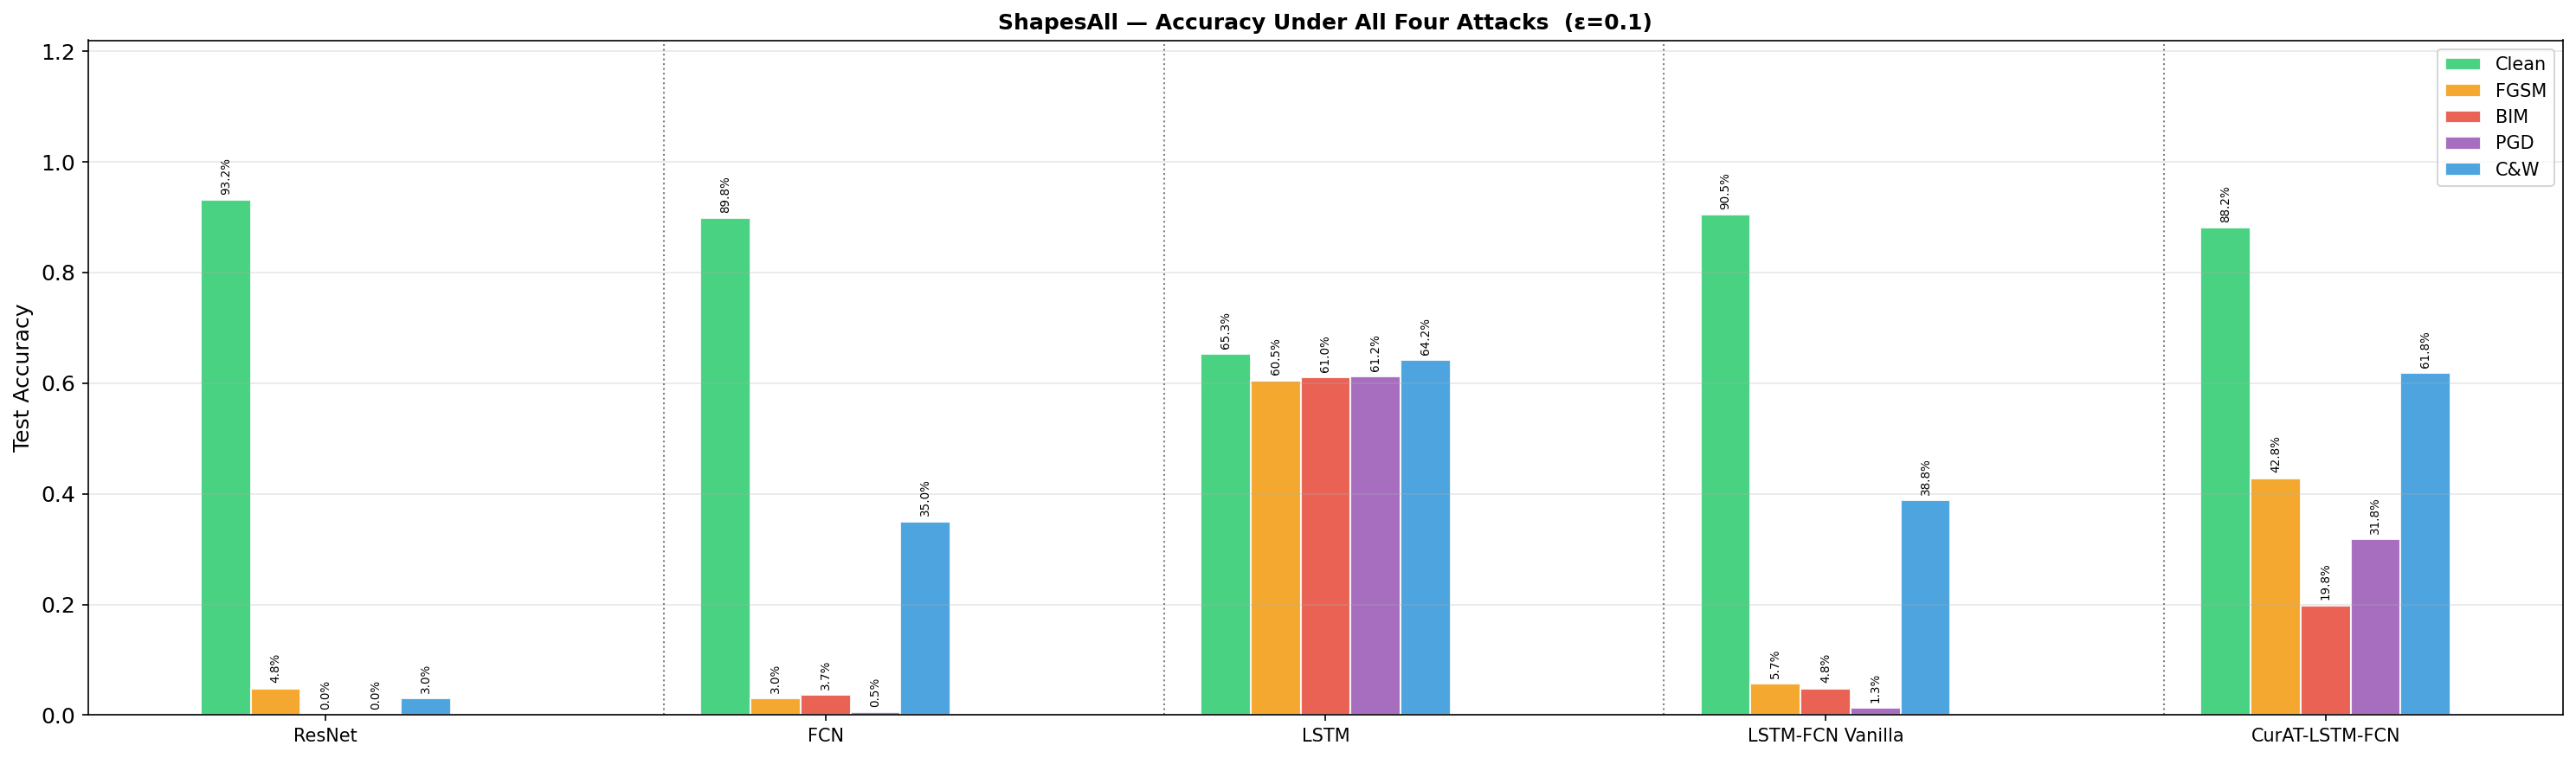

✓ Saved: bar_all_attacks.png


In [ ]:
fig, ax = plt.subplots(figsize=(20, 6))
n_bars    = 5
x         = np.arange(len(model_names)) * (n_bars + 1.5)
width     = 0.65
bar_cols  = ['#2ecc71','#f39c12','#e74c3c','#9b59b6','#3498db']
bar_lbls  = ['Clean','FGSM','BIM','PGD','C&W']
bar_akeys = ['Clean','FGSM','BIM','PGD','CW']

for i, (lbl, akey, color) in enumerate(zip(bar_lbls, bar_akeys, bar_cols)):
    vals = [acc_matrix[m][akey] for m in model_names]
    bars = ax.bar(x + i*width, vals, width,
                  label=lbl, color=color, edgecolor='white', alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.annotate(f'{v*100:.1f}%',
                    xy=(bar.get_x()+bar.get_width()/2, v),
                    xytext=(0,3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x + width*2); ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title(f"{DATASET_NAME} — Accuracy Under All Four Attacks  (ε={EPSILON})",
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.22); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
for xi in x[1:]: ax.axvline(xi-0.8, color='gray', ls=':', lw=1.0)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/bar_all_attacks.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: bar_all_attacks.png")


### CELL 19 | Accuracy Drop Heatmap

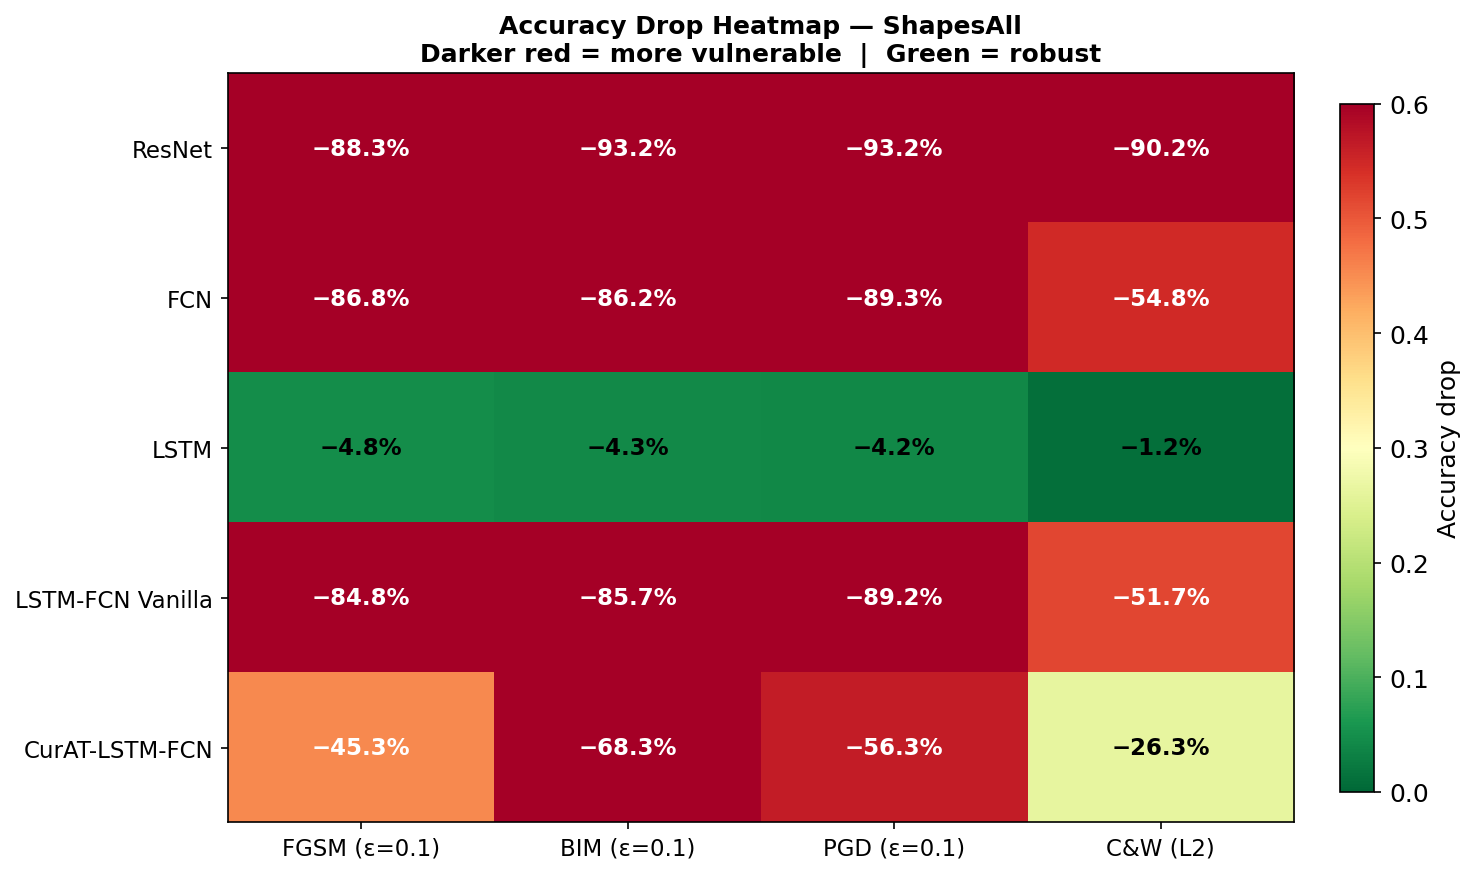

✓ Saved: drop_heatmap.png


In [ ]:
drop_mat = np.array([
    [acc_matrix[m]['Clean'] - acc_matrix[m][k]
     for k in ['FGSM','BIM','PGD','CW']]
    for m in model_names])

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(drop_mat, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.60)
ax.set_xticks(range(4))
ax.set_xticklabels(['FGSM (ε=0.1)','BIM (ε=0.1)','PGD (ε=0.1)','C&W (L2)'], fontsize=11)
ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names, fontsize=11)
ax.set_title(f"Accuracy Drop Heatmap — {DATASET_NAME}\n"
             "Darker red = more vulnerable  |  Green = robust",
             fontsize=12, fontweight='bold')
for i in range(len(model_names)):
    for j in range(4):
        d = drop_mat[i,j]
        ax.text(j, i, f"−{d*100:.1f}%", ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if d > 0.35 else 'black')
plt.colorbar(im, ax=ax, label='Accuracy drop', fraction=0.03, pad=0.04)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/drop_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: drop_heatmap.png")


### CELL 20 | Training History — All 5 Models

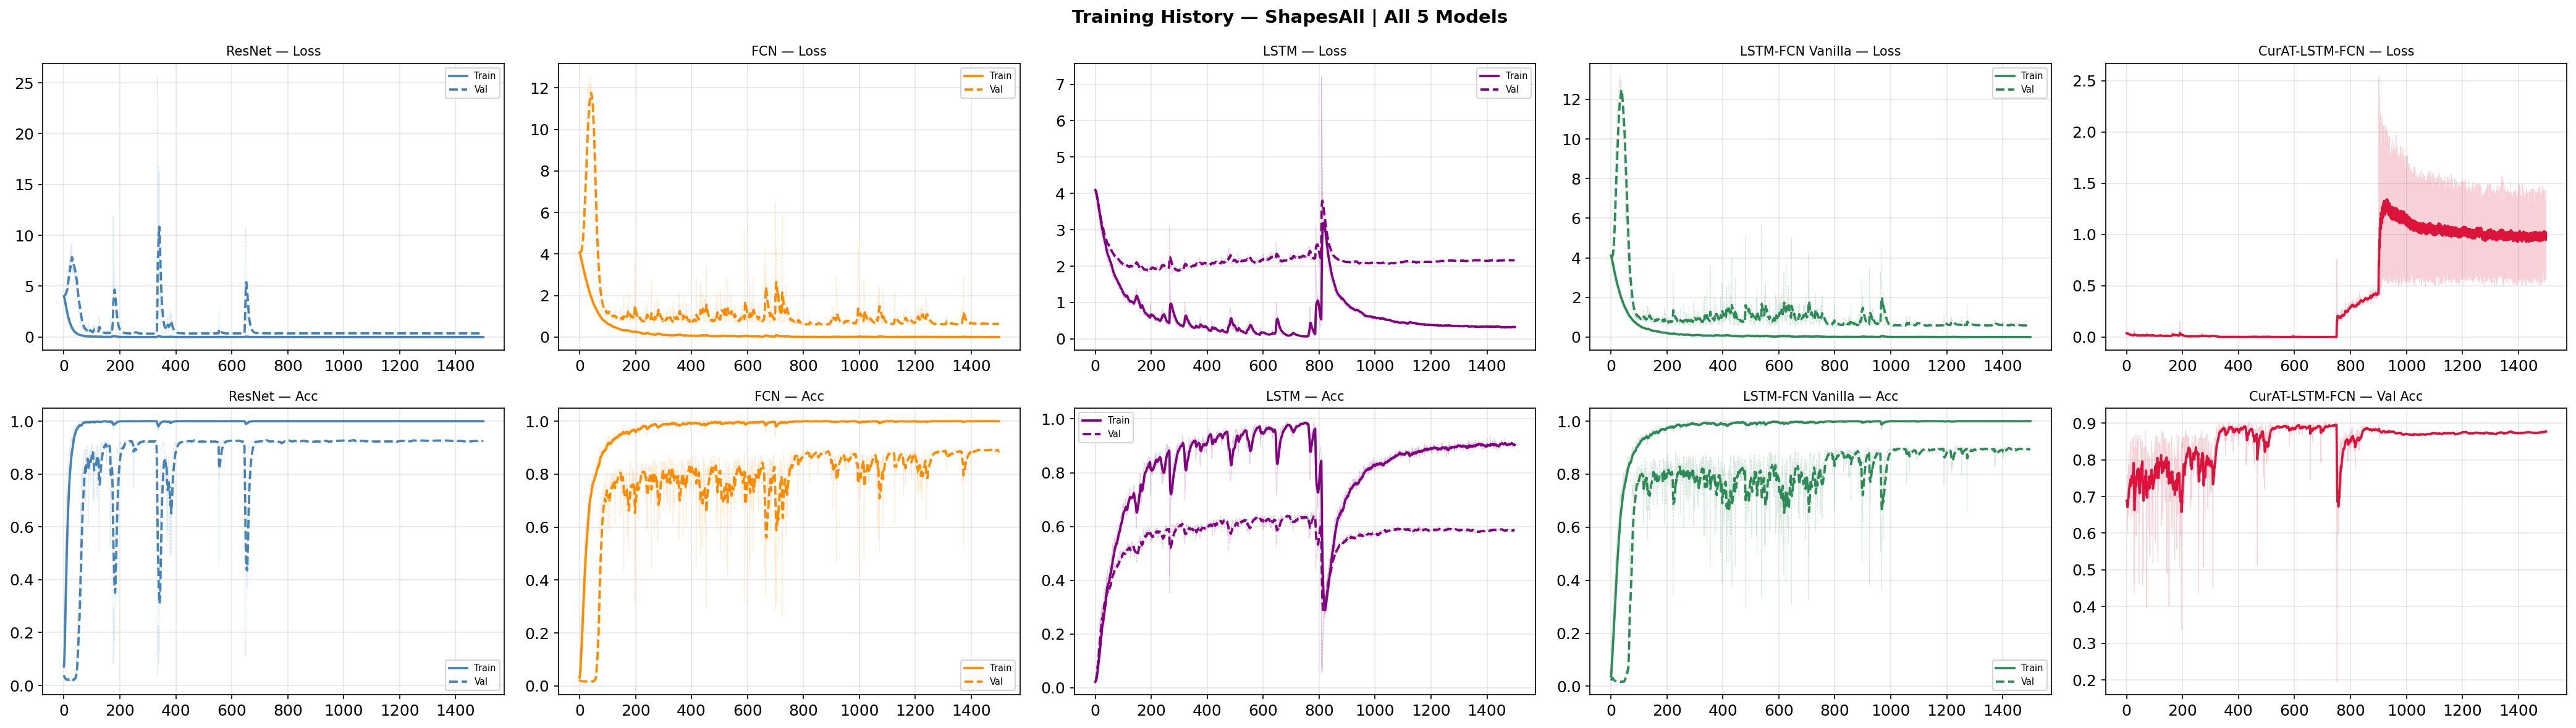

✓ Saved: training_history_all.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(28, 8))
fig.suptitle(f"Training History — {DATASET_NAME} | All 5 Models",
             fontsize=14, fontweight='bold')

std_models = [
    (hist_resnet,  'ResNet',           'steelblue'),
    (hist_fcn,     'FCN',              'darkorange'),
    (hist_lstm,    'LSTM',             'purple'),
    (hist_vanilla, 'LSTM-FCN Vanilla', 'seagreen'),
]

for col, (h, name, color) in enumerate(std_models):
    for row, (tr_k, val_k, label) in enumerate([
            ('loss','val_loss','Loss'),
            ('accuracy','val_accuracy','Acc')]):
        rtr  = h.get(tr_k,  [0])
        rval = h.get(val_k, [0])
        axes[row,col].plot(rtr,               color=color, lw=0.5, alpha=0.2)
        axes[row,col].plot(rval,              color=color, lw=0.5, alpha=0.2, ls='--')
        axes[row,col].plot(smooth_curve(rtr), color=color, lw=1.8, label='Train')
        axes[row,col].plot(smooth_curve(rval),color=color, lw=1.8, ls='--', label='Val')
        axes[row,col].set_title(f"{name} — {label}", fontsize=10)
        axes[row,col].legend(fontsize=7); axes[row,col].grid(alpha=0.3)

# CurAT column
adv_l = hist_robust.get('loss', [0])
adv_v = hist_robust.get('val_accuracy', [0])
axes[0,4].plot(adv_l,               color='crimson', lw=0.5, alpha=0.2)
axes[0,4].plot(smooth_curve(adv_l), color='crimson', lw=1.8)
axes[0,4].set_title("CurAT-LSTM-FCN — Loss", fontsize=10); axes[0,4].grid(alpha=0.3)
axes[1,4].plot(adv_v,               color='crimson', lw=0.5, alpha=0.2)
axes[1,4].plot(smooth_curve(adv_v), color='crimson', lw=1.8)
axes[1,4].set_title("CurAT-LSTM-FCN — Val Acc", fontsize=10); axes[1,4].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_history_all.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: training_history_all.png")


### CELL 21 | LSTM-FCN Vanilla vs CurAT-LSTM-FCN Comparison

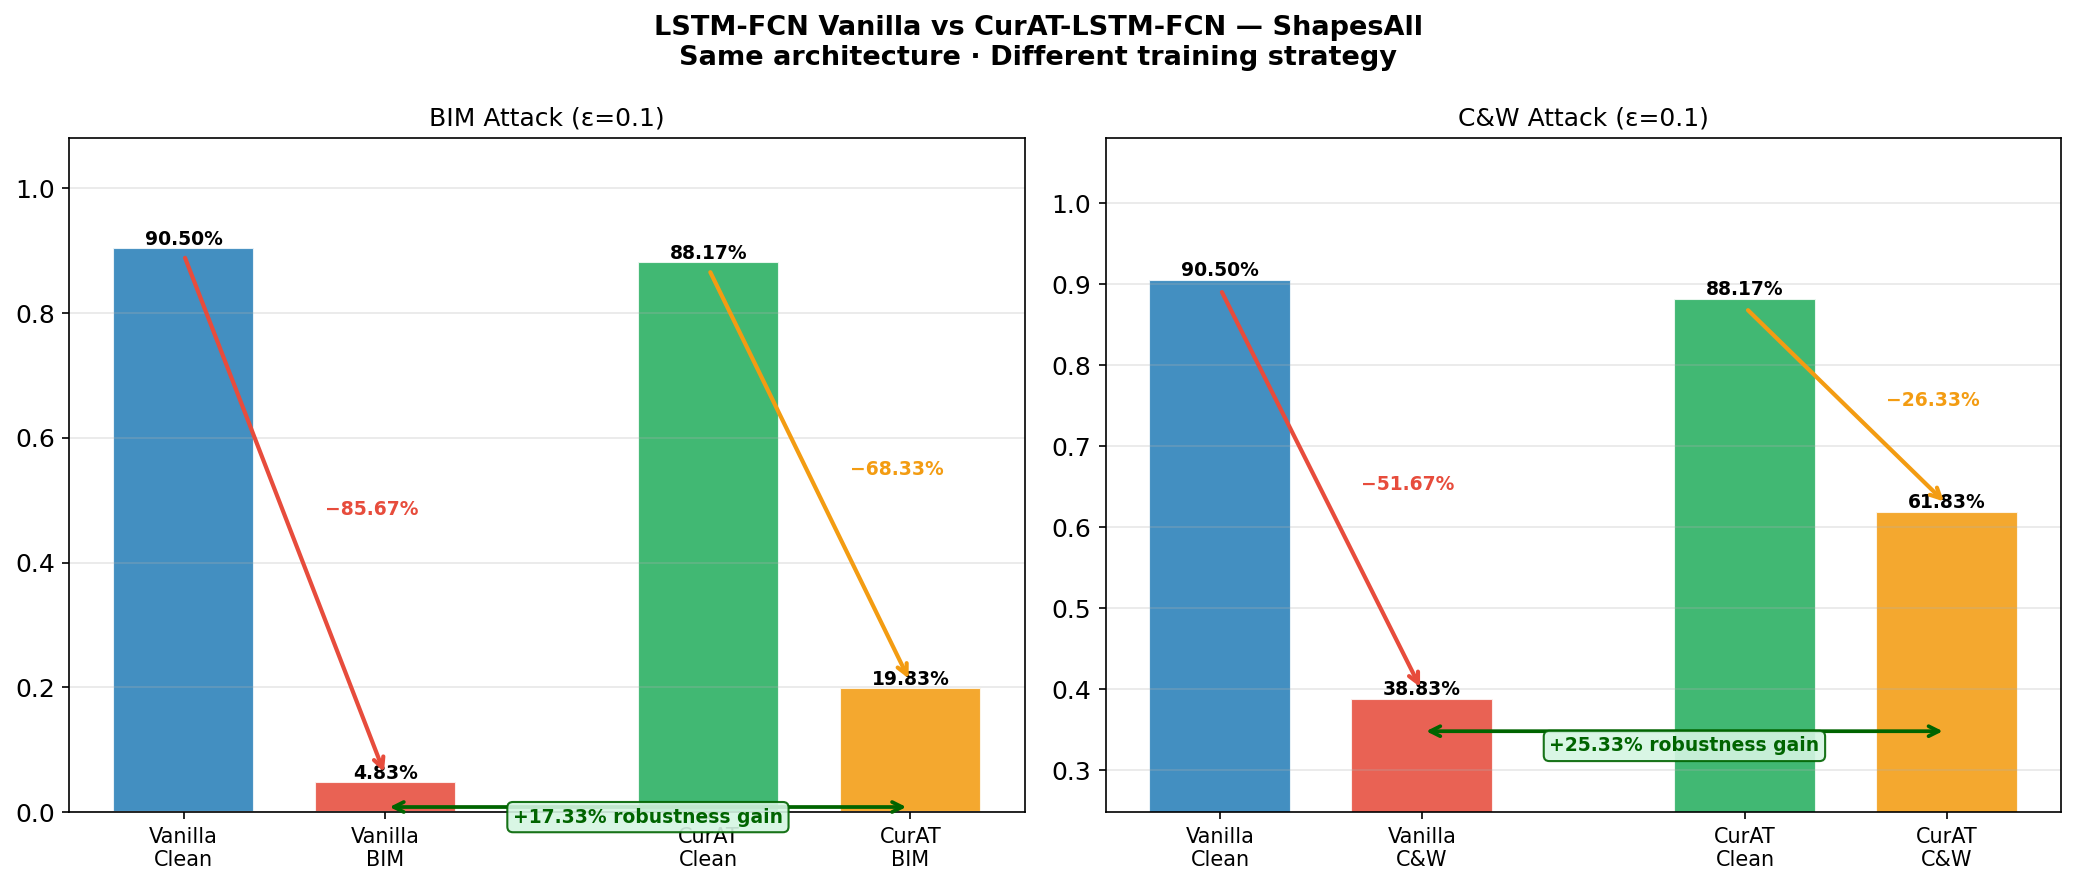

✓ Saved: vanilla_vs_curat.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"LSTM-FCN Vanilla vs CurAT-LSTM-FCN — {DATASET_NAME}\n"
    "Same architecture · Different training strategy",
    fontsize=13, fontweight='bold')

v_clean = acc_matrix['LSTM-FCN Vanilla']['Clean']
r_clean = acc_matrix['CurAT-LSTM-FCN']['Clean']

for col, (aname, akey) in enumerate([('BIM','BIM'),('C&W','CW')]):
    ax   = axes[col]
    va   = acc_matrix['LSTM-FCN Vanilla'][akey]
    ra   = acc_matrix['CurAT-LSTM-FCN'][akey]
    gain = (v_clean - va) - (r_clean - ra)
    bars = ax.bar([0,1,2.6,3.6], [v_clean,va,r_clean,ra],
                  color=['#2980b9','#e74c3c','#27ae60','#f39c12'],
                  edgecolor='white', width=0.7, alpha=0.88)
    for bar, v in zip(bars, [v_clean,va,r_clean,ra]):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
                f"{v*100:.2f}%", ha='center', fontsize=9, fontweight='bold')
    for x0,x1,y0,y1,c in [(0,1,v_clean,va,'#e74c3c'),(2.6,3.6,r_clean,ra,'#f39c12')]:
        ax.annotate('', xy=(x1,y1+0.01), xytext=(x0,y0-0.01),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2.0))
        ax.text((x0+x1)/2+0.2,(y0+y1)/2,
                f"−{(y0-y1)*100:.2f}%", fontsize=9, color=c, fontweight='bold')
    y_b = min(va,ra)-0.04
    ax.annotate('', xy=(1,y_b), xytext=(3.6,y_b),
                arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=1.8))
    ax.text(2.3, y_b-0.025, f"+{gain*100:.2f}% robustness gain",
            ha='center', fontsize=9, color='darkgreen', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#d5f5e3',
                      edgecolor='darkgreen', alpha=0.9))
    ax.set_xticks([0,1,2.6,3.6])
    ax.set_xticklabels(['Vanilla\nClean',f'Vanilla\n{aname}',
                        'CurAT\nClean',f'CurAT\n{aname}'], fontsize=10)
    ax.set_title(f"{aname} Attack (ε={EPSILON})", fontsize=12)
    ax.set_ylim(max(0, min(v_clean,va,r_clean,ra)-0.14), 1.08)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/vanilla_vs_curat.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: vanilla_vs_curat.png")


### CELL 22 | Epsilon Sweep

Running epsilon sweep...
  ε=0.01 done
  ε=0.05 done
  ε=0.10 done
  ε=0.20 done
  ε=0.30 done
  ε=0.50 done
  ε=0.75 done
  ε=1.00 done


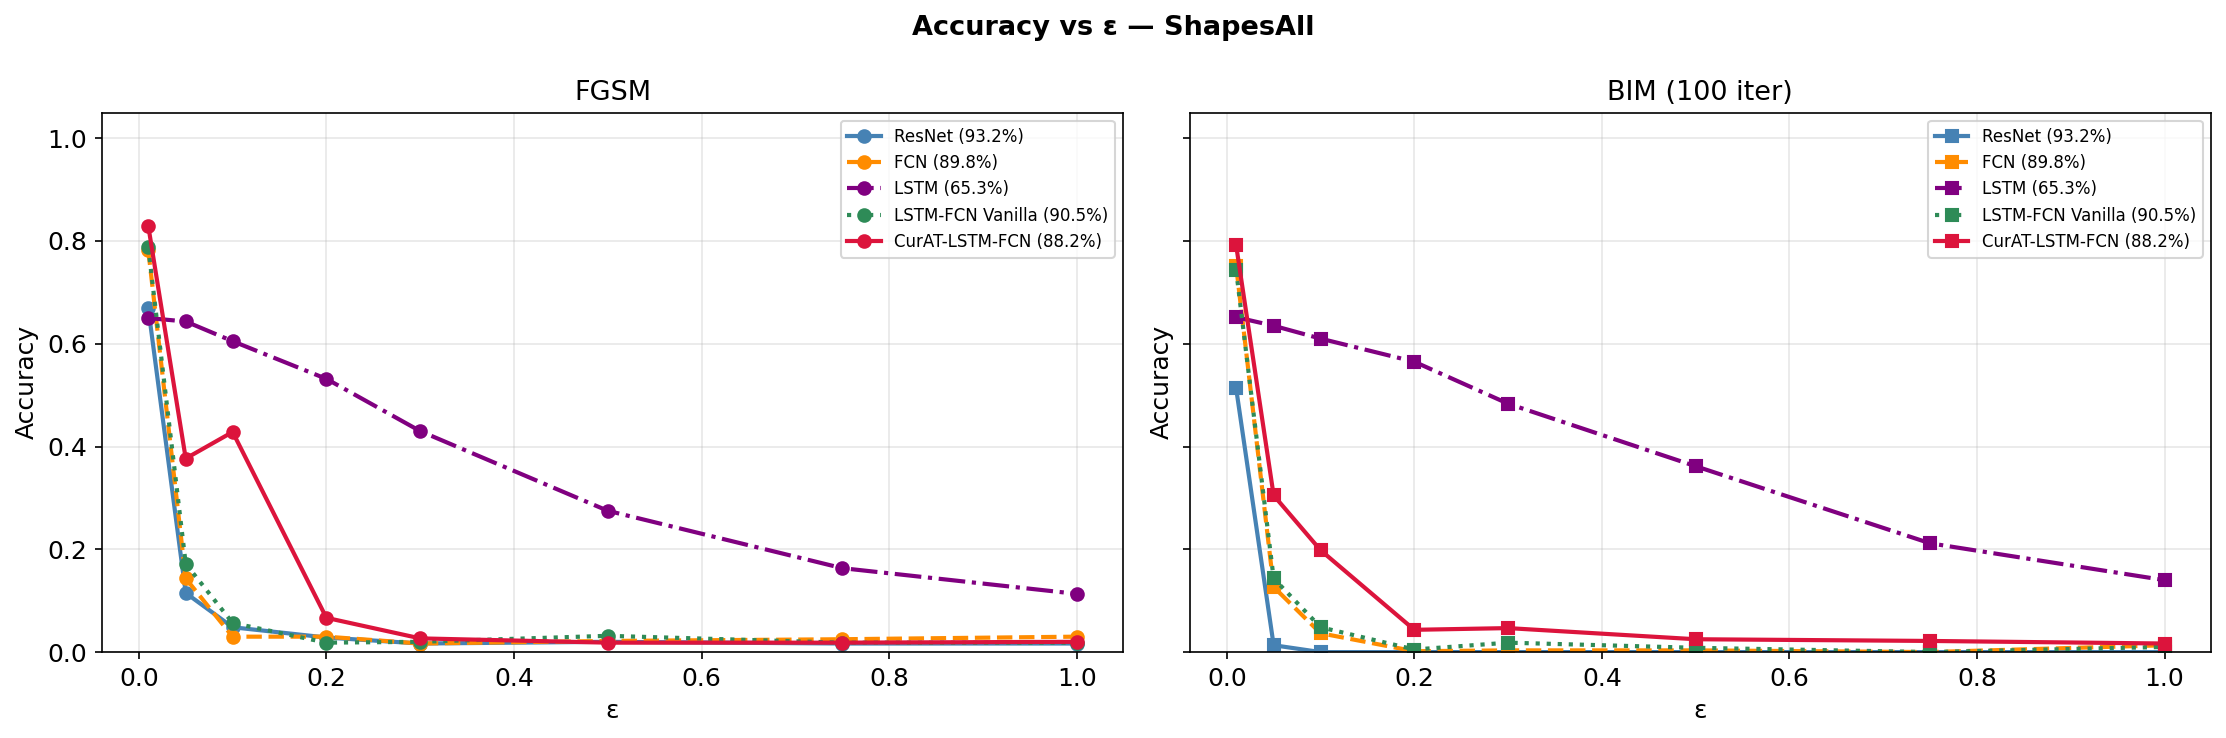

✓ Saved: epsilon_sweep.png


In [ ]:
eps_vals = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
sweep    = {m: {'fgsm':[], 'bim':[]} for m in model_names}
print("Running epsilon sweep...")
for eps in eps_vals:
    Xf = fgsm_attack(resnet_model, X_test, y_test_cat, epsilon=eps)
    Xb = bim_attack( resnet_model, X_test, y_test_cat, epsilon=eps, num_iter=100)
    for mname, model in all_models.items():
        sweep[mname]['fgsm'].append(
            accuracy_score(y_test_int, np.argmax(model.predict(Xf,verbose=0),axis=1)))
        sweep[mname]['bim'].append(
            accuracy_score(y_test_int, np.argmax(model.predict(Xb,verbose=0),axis=1)))
    print(f"  ε={eps:.2f} done")

mc = {'ResNet':'steelblue','FCN':'darkorange','LSTM':'purple',
      'LSTM-FCN Vanilla':'seagreen','CurAT-LSTM-FCN':'crimson'}
ms = {'ResNet':'-','FCN':'--','LSTM':'-.',
      'LSTM-FCN Vanilla':':', 'CurAT-LSTM-FCN':'-'}

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15,5), sharey=True)
fig.suptitle(f"Accuracy vs ε — {DATASET_NAME}", fontsize=13, fontweight='bold')
for mname in model_names:
    c  = acc_matrix[mname]['Clean']
    kw = dict(color=mc[mname], linestyle=ms[mname], linewidth=2.0,
              label=f"{mname} ({c*100:.1f}%)")
    ax1.plot(eps_vals, sweep[mname]['fgsm'], 'o', **kw)
    ax2.plot(eps_vals, sweep[mname]['bim'],  's', **kw)
for ax, title in [(ax1,'FGSM'),(ax2,'BIM (100 iter)')]:
    ax.set_xlabel("ε"); ax.set_ylabel("Accuracy")
    ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/epsilon_sweep.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: epsilon_sweep.png")


### CELL 23 | Final Summary + Download All Figures

In [ ]:
# ── Console summary ───────────────────────────────────────────────────────────
SEP = "="*95
print(f"\n{SEP}")
print(f"  FINAL SUMMARY — {DATASET_NAME}")
print(SEP)
print(f"  {'Model':<22} {'Clean':>8} {'FGSM':>8} {'BIM':>8} {'PGD':>8} {'C&W':>8}  Mode")
print("  " + "-"*78)
for mname in model_names:
    al = acc_matrix[mname]
    print(f"  {mname:<22} "
          f"{al['Clean']*100:>7.2f}% "
          f"{al['FGSM']*100:>7.2f}% "
          f"{al['BIM']*100:>7.2f}% "
          f"{al['PGD']*100:>7.2f}% "
          f"{al['CW']*100:>7.2f}%  "
          f"{attack_mode[mname]}")
print(SEP)

# ── Save summary JSON to Drive ────────────────────────────────────────────────
summary = {
    'dataset': DATASET_NAME,
    'epsilon': EPSILON,
    'results': {mname: {k:round(v,4) for k,v in acc_matrix[mname].items()}
                for mname in model_names}
}
with open(f"{CKPT_DIR}/final_results.json", 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n✓ Results JSON saved to Drive.")

# ── Zip + Download ────────────────────────────────────────────────────────────
import shutil
from google.colab import files
zip_path = f"/content/{DATASET_NAME}_all_results"
shutil.make_archive(zip_path, 'zip', SAVE_DIR)
print(f"✓ Created {zip_path}.zip — downloading now...")
files.download(f"{zip_path}.zip")
print("\n  ★ To run next dataset: change DATASET_NAME in Cell 2 and run all cells ★")



  FINAL SUMMARY — ShapesAll
  Model                     Clean     FGSM      BIM      PGD      C&W  Mode
  ------------------------------------------------------------------------------
  ResNet                   93.17%    4.83%    0.00%    0.00%    3.00%  White-box
  FCN                      89.83%    3.00%    3.67%    0.50%   35.00%  Black-box
  LSTM                     65.33%   60.50%   61.00%   61.17%   64.17%  Black-box
  LSTM-FCN Vanilla         90.50%    5.67%    4.83%    1.33%   38.83%  Black-box
  CurAT-LSTM-FCN           88.17%   42.83%   19.83%   31.83%   61.83%  Black-box

✓ Results JSON saved to Drive.
✓ Created /content/ShapesAll_all_results.zip — downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  ★ To run next dataset: change DATASET_NAME in Cell 2 and run all cells ★
